# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії — від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа — підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 — основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

### Підготовка середовища

In [1]:
# ставлю тільки те, чого немає (у Colab torch, pandas, sklearn уже є)
import importlib.util, subprocess, sys
for pkg in ["datasets", "tensorboard", "gradio"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.tensorboard import SummaryWriter
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

RUNS_DIR = "runs"
MODELS_DIR = "models"
shutil.rmtree(RUNS_DIR, ignore_errors=True)  # щоб при повторному запуску логи не дублювались
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
print("torch", torch.__version__)

torch 2.14.1+cpu


## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.1 Мої відповіді:

1. У демо пропуски були у всіх 8 ознаках, рядків з пропусками 1241 з 12384 (10%). Видаляти їх шкода, бо втратимо 10% даних. Медіана ставить усім одне й те саме значення і не дивиться на інші ознаки рядка. kNN шукає 5 найбільш схожих рядків за рештою ознак і бере їх середнє, тобто враховує зв'язки між ознаками, а в демо ознаки якраз пов'язані між собою (наприклад, кімнати і спальні, координати). Плюс у демо всі ознаки числові, а kNN працює саме з числовими. Моделі kNN навчаються тільки на train, щоб не було leakage.

2. Під час тренування MSE це функція втрат: саме її мінімізує оптимізатор. Тому train і val порівнюють по ній, щоб бачити, чи падає помилка і чи не почалось перенавчання. Інші метрики на це не впливають, тому під час навчання вони не потрібні. Після тренування модель треба оцінити так, щоб це було зрозуміло: RMSE і MAE в одиницях таргету (на скільки в середньому помиляємось), R² показує, наскільки модель краща за прогноз середнім. Експеримент зробив на своєму датасеті (2.2, після ваг): лінійна модель з MSE, MAE (L1) і Huber як функцією втрат. Кожна функція втрат виграє "свою" метрику: з MSELoss найменша val MSE (4.985), з L1Loss найменша val MAE (1.582 проти 1.637). Huber посередині. Тобто функцію втрат треба обирати під ту метрику, яка важлива в задачі.

3. Після 2.6 видно, що головна ознака MedInc (вага 0.83): чим вищий дохід у районі, тим дорожчі будинки. Друга і третя за силою це diag_coord (-0.30) і bedperroom (0.20), тобто ознаки, які створили в 1.8. Значить, feature engineering себе виправдав. Population (-0.001) і AveOccup (-0.04) майже нічого не дають, їх можна було б прибрати. Ваги можна так порівнювати тільки тому, що ознаки стандартизовані. При цьому вага показує вплив ознаки за умови, що інші не змінюються, а не причину.

4. Baseline це найпростіший прогноз, з яким порівнюють модель, щоб зрозуміти, чи вона взагалі чогось навчилась. У лінійній регресії (демо 2.5) baseline це середнє значення таргету на train, яке прогнозується для всіх рядків: `np.full_like(y_test, y_train.mean())`. У нього R² близько 0 (у демо -0.0009). Якщо модель не краща за нього, вона марна. Для нейромережі baseline це вже навчена лінійна регресія: нейромережа має сенс, тільки якщо вона краща за просту лінійну модель (у демо 0.3683 проти 0.5497 MSE).

5. Графік нижче. ReLU обнуляє все від'ємне, Leaky ReLU залишає маленький нахил для від'ємних (я взяв 0.1 замість стандартного 0.01, щоб нахил було видно), Sigmoid стискає в (0, 1), Tanh в (-1, 1).

6. У демо після 1.8 залишається 7 ознак, мережа 7 -> 64 -> 32 -> 1. Кожен `nn.Linear(a, b)` має a*b ваг і b bias: 7*64+64 = 512, 64*32+32 = 2080, 32*1+1 = 33. Разом 2625. У ReLU параметрів немає. Для порівняння у лінійної моделі 7+1 = 8 параметрів, тобто в 328 разів менше. Розрахунок у коді нижче.

7. Ні, 200 епох замало. На кінці навчання і train, і val ще падають (у демо val 0.3738 на 190 епосі і 0.3712 на 199), перенавчання немає. Я навчив ту саму мережу довше: val MSE на 400 епосі 0.343, на 600 епосі 0.331, найменше значення 0.325 приблизно на 900 епосі, а далі val вже починає трохи рости. Тобто оптимально десь 800-900 епох, або ставити більше і зупиняти навчання, коли val перестає падати.

Код до питань 5 і 6:

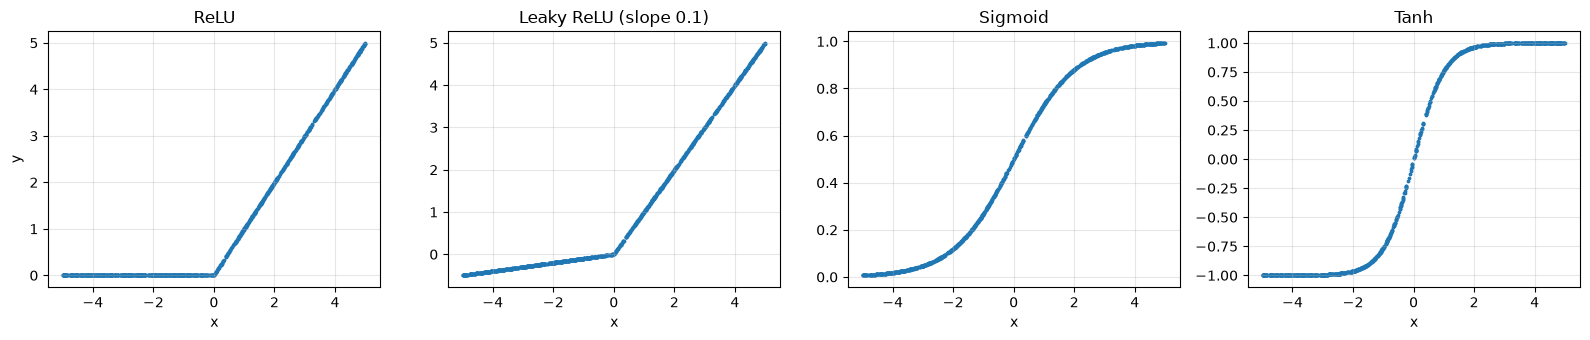

In [2]:
# 5. 1000 випадкових X від -5 до 5 через кожну функцію активації
x = torch.rand(1000) * 10 - 5
activations = {
    "ReLU": nn.ReLU(),
    "Leaky ReLU (slope 0.1)": nn.LeakyReLU(0.1),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, f) in zip(axes, activations.items()):
    ax.scatter(x, f(x), s=3)
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

In [3]:
# 6. параметри мережі з демо: 7 ознак -> 64 -> 32 -> 1
sizes = [7, 64, 32, 1]
total = 0
for a, b in zip(sizes[:-1], sizes[1:]):
    print(f"Linear({a}, {b}): {a}*{b} ваг + {b} bias = {a * b + b}")
    total += a * b + b
print("Разом:", total)

Linear(7, 64): 7*64 ваг + 64 bias = 512
Linear(64, 32): 64*32 ваг + 32 bias = 2080
Linear(32, 1): 32*1 ваг + 1 bias = 33
Разом: 2625


---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі — задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** — 21 613 продажів будинків (Вашингтон, 2014–2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) — вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** — 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** — 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** — 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** — 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3–9). Усі ознаки — хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** — 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) — доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** — 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** — 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку — гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** — 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак — хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) — вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** — 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки — фізичні виміри, окрім `sex`.

Решта (2–5, 7–8, 10) вантажаться напряму — `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 — це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи — `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [4]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Перегуда Владислав Анатолійович"

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])

Ваш датасет (#10): Abalone


---
## 2. Що потрібно зробити

Нижче — загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача — повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) — рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) — і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) — **якщо вони є**. Немає пропусків — так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних — capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) — **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) — **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test — MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично — напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна — окремий варіант.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** — інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** — якщо є час і бажання поекспериментувати більше, це тільки заохочується.

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) — з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

---
## Виконання: Abalone

Задача: за розмірами і масою молюска передбачити кількість кілець `number_of_rings` (вік = кільця + 1.5 року).

### 2.1.1 Завантаження

In [5]:
abalone = load_dataset("mstz/abalone")
print(abalone)
df = abalone["train"].to_pandas()
TARGET = "number_of_rings"
print("Розмір:", df.shape)

DatasetDict({
    train: Dataset({
        features: ['sex', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'number_of_rings'],
        num_rows: 4177
    })
})
Розмір: (4177, 9)


### 2.1.2 Спліт train / val / test

Ділю одразу, до будь-якого аналізу: 70% train, 15% val, 15% test. Якщо спочатку подивитись на всі дані (середні, викиди, кореляції), то рішення про обробку будуть враховувати й test, і оцінка на test вийде занадто оптимістичною. Це і є data leakage. Тому далі всі статистики (медіана, scaler) рахую тільки на train, а val і test лише перетворюю тими самими правилами.

In [6]:
train_df, tmp_df = train_test_split(df, test_size=0.3, random_state=SEED)
val_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=SEED)
print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)

train: (2923, 9) val: (627, 9) test: (627, 9)


### 2.1.3 Загальний огляд

In [7]:
train_df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
2830,F,0.525,0.430,0.135,0.8435,0.4325,0.1800,0.1815,9
925,I,0.430,0.325,0.100,0.3645,0.1575,0.0825,0.1050,7
3845,M,0.455,0.350,0.105,0.4160,0.1625,0.0970,0.1450,11
547,M,0.205,0.155,0.045,0.0425,0.0170,0.0055,0.0155,7
2259,F,0.590,0.465,0.160,1.1005,0.5060,0.2525,0.2950,13


In [8]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 2923 entries, 2830 to 860
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              2923 non-null   str    
 1   length           2923 non-null   float64
 2   diameter         2923 non-null   float64
 3   height           2923 non-null   float64
 4   whole_weight     2923 non-null   float64
 5   shucked_weight   2923 non-null   float64
 6   viscera_weight   2923 non-null   float64
 7   shell_weight     2923 non-null   float64
 8   number_of_rings  2923 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 231.6 KB


In [9]:
train_df.describe()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
count,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000
mean,0.526143,0.409531,0.140128,0.836328,0.362982,0.182291,0.241286,9.983921
std,0.119723,0.098994,0.042487,0.492079,0.223530,0.109229,0.140562,3.238851
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.443750,0.187000,0.094500,0.130000,8.000000
50%,0.545000,0.425000,0.145000,0.808500,0.340000,0.173000,0.235000,10.000000
75%,0.615000,0.485000,0.165000,1.160250,0.508250,0.256000,0.330000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### 2.1.4 Пропуски

In [10]:
pd.DataFrame({"train": train_df.isna().sum(), "val": val_df.isna().sum(), "test": test_df.isna().sum()})

,train,val,test
sex,0,0,0
length,0,0,0
diameter,0,0,0
height,0,0,0
whole_weight,0,0,0
shucked_weight,0,0,0
viscera_weight,0,0,0
shell_weight,0,0,0
number_of_rings,0,0,0


Пропусків немає ні в train, ні у val, ні в test, тому заповнювати нічого не треба. Але є нулі в height, які по суті теж є помилкою запису, про них нижче у викидах.

### 2.1.5 EDA

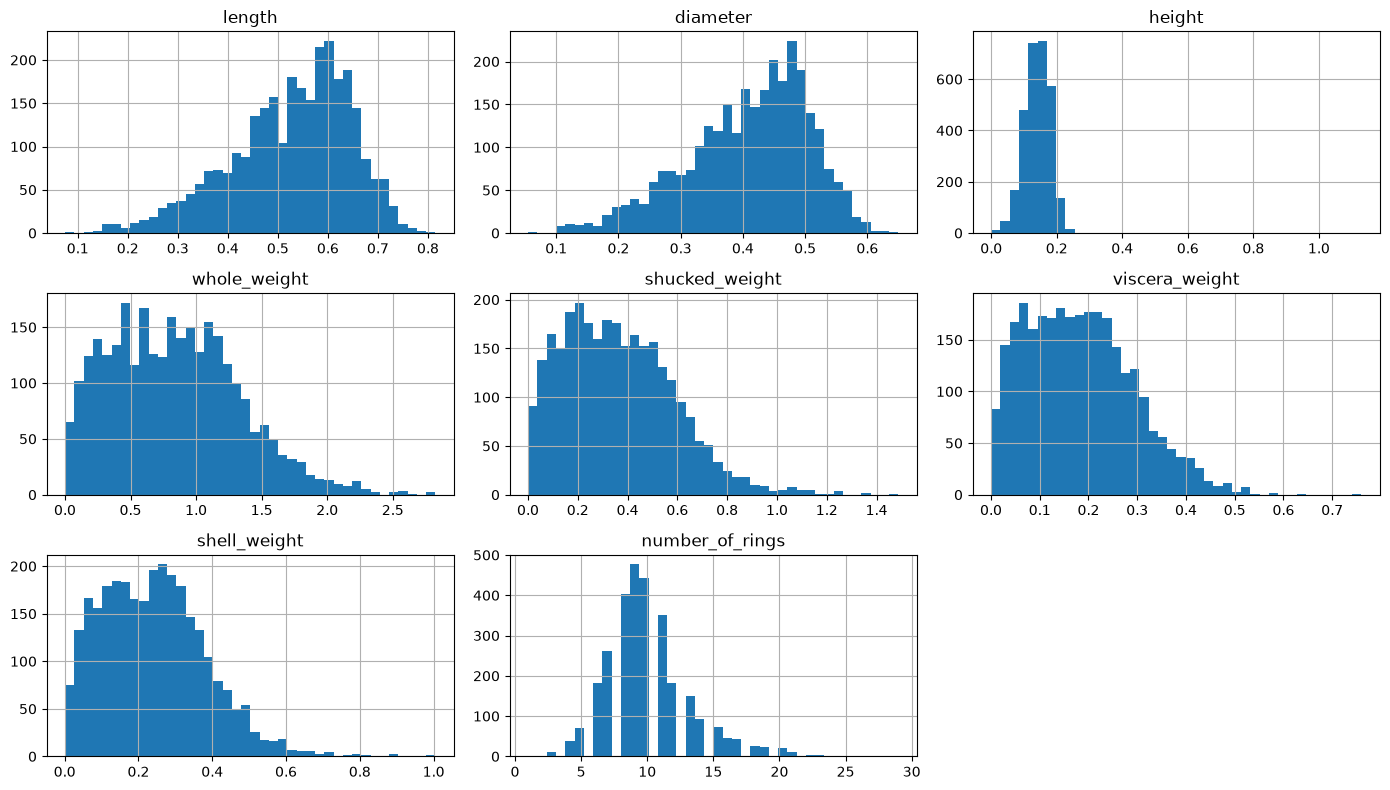

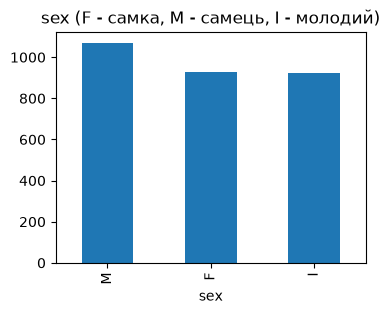

In [11]:
train_df.hist(bins=40, figsize=(14, 8))
plt.tight_layout()
plt.show()

train_df["sex"].value_counts().plot.bar(title="sex (F - самка, M - самець, I - молодий)", figsize=(4, 3))
plt.show()

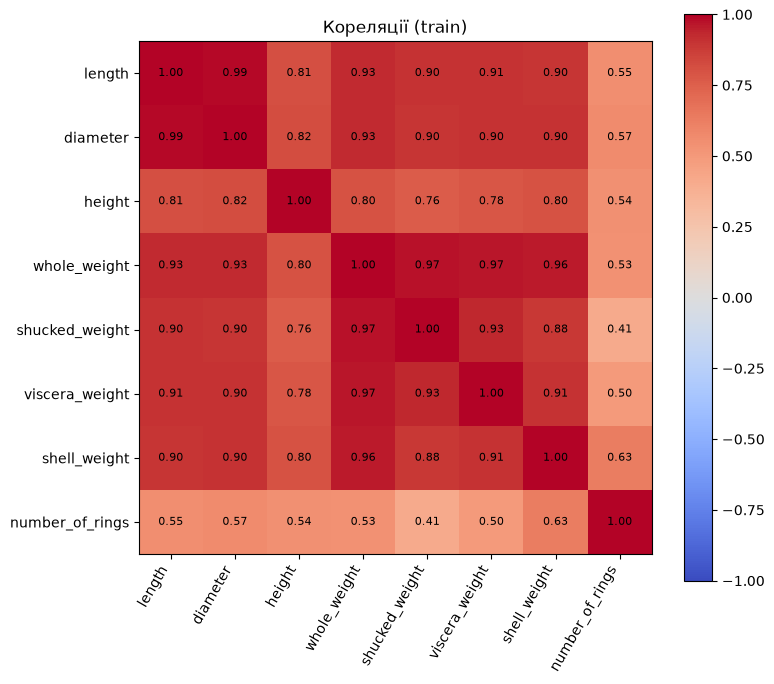

Кореляція з таргетом:
shell_weight      0.625
diameter          0.566
length            0.550
height            0.544
whole_weight      0.535
viscera_weight    0.499
shucked_weight    0.414
Name: number_of_rings, dtype: float64

sex
F    11.13
I     7.99
M    10.71
Name: number_of_rings, dtype: float64


In [12]:
corr = train_df.drop(columns="sex").corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im)
plt.title("Кореляції (train)")
plt.tight_layout()
plt.show()

print("Кореляція з таргетом:")
print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3))
print()
print(train_df.groupby("sex")[TARGET].mean().round(2))

Що видно:
- Таргет `number_of_rings` від 1 до 29, більшість 5-15 (92% рядків), розподіл скошений вправо (skew 1.13). Обрізання (capping) немає: на максимумі немає стовпчика, 29 кілець лише в одного молюска.
- Маси скошені вправо, length і diameter трохи вліво. У height є явні викиди: максимум 1.13 при тому, що майже всі значення до 0.25, і є нулі.
- Сильна мультиколінеарність: length і diameter 0.99, маси між собою 0.9 і більше. По суті це все "розмір молюска".
- З таргетом усі ознаки корелюють помірно (0.41-0.63), найсильніше shell_weight (0.63). Жодна ознака сама не дає точного віку.
- Молоді (I) мають помітно менше кілець (8.0), ніж F (11.1) і M (10.7), тому sex треба залишити.

### 2.1.6 Викиди

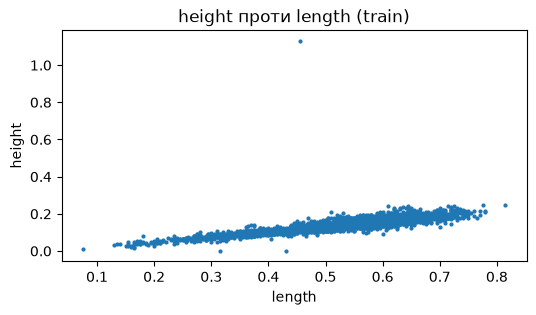

Підозріла height:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
2051,F,0.455,0.355,1.13,0.594,0.3320,0.1160,0.1335,8
3996,I,0.315,0.230,0.00,0.134,0.0575,0.0285,0.3505,6
1257,I,0.430,0.340,0.00,0.428,0.2065,0.0860,0.1150,8


Частина важча за весь молюск:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
3996,I,0.315,0.23,0.000,0.134,0.0575,0.0285,0.3505,6
3086,I,0.355,0.27,0.075,0.204,0.3045,0.0460,0.0595,7


In [13]:
plt.figure(figsize=(6, 3))
plt.scatter(train_df["length"], train_df["height"], s=4)
plt.xlabel("length")
plt.ylabel("height")
plt.title("height проти length (train)")
plt.show()

bad_height = (train_df["height"] == 0) | (train_df["height"] > 0.3)
print("Підозріла height:")
display(train_df[bad_height])

# частина молюска не може важити більше, ніж увесь молюск
bad_weight = (train_df["shucked_weight"] > train_df["whole_weight"]) | (train_df["shell_weight"] > train_df["whole_weight"])
print("Частина важча за весь молюск:")
display(train_df[bad_weight])

Викиди:
- height = 1.13 при length 0.455: висота більша за довжину вдвічі, такого молюска не буває, це помилка запису (на графіку точка дуже далеко від решти). height = 0 теж неможливо. Правило: height = 0 або height > 0.3 вважаю помилкою і замінюю на медіану height з train. Замінюю, а не видаляю, бо таке саме може трапитися в нових даних (val, test, аппка), і модель має з цим працювати.
- Два рядки, де м'ясо або мушля важать більше, ніж увесь молюск. Це теж помилка, і що з цього правильне, невідомо. Їх лише 2 з 2923, тому просто видаляю з train.
- Великі маси і великі значення кілець (20+) не чіпаю: це справжні старі великі молюски, їх видалення зробило б модель гіршою саме на старих.

In [14]:
# медіана height тільки з нормальних рядків train
height_median = train_df.loc[~bad_height, "height"].median()
print("Медіана height:", height_median)

train_df = train_df[~bad_weight]
print("train після видалення:", train_df.shape)

Медіана height: 0.145
train після видалення: (2921, 9)


### 2.1.7 Інженерія ознак

Інженерія ознак:
- `diameter` прибираю: кореляція з length 0.99, нової інформації вона майже не дає.
- Маси залишаю всі, хоча вони сильно корелюють між собою: у них різний зміст (м'ясо, нутрощі, мушля), і shell_weight найкраще корелює з віком.
- `sex` текстова, тому роблю два стовпці 0/1: sex_I і sex_M (самка F базова).

In [15]:
num_cols = ["length", "height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight"]

def prepare(frame):
    X = frame[num_cols].copy()
    # нульова або нереально велика висота це помилка запису, ставлю медіану з train
    wrong = (X["height"] == 0) | (X["height"] > 0.3)
    X.loc[wrong, "height"] = height_median
    # sex -> два стовпці 0/1, самка (F) базова категорія
    X["sex_I"] = (frame["sex"] == "I").astype(float)
    X["sex_M"] = (frame["sex"] == "M").astype(float)
    return X

X_train_df = prepare(train_df)
X_val_df = prepare(val_df)
X_test_df = prepare(test_df)
feature_cols = list(X_train_df.columns)
print("Ознаки:", feature_cols)
X_train_df.head()

Ознаки: ['length', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'sex_I', 'sex_M']


,length,height,whole_weight,shucked_weight,viscera_weight,shell_weight,sex_I,sex_M
2830,0.525,0.135,0.8435,0.4325,0.1800,0.1815,0.0,0.0
925,0.430,0.100,0.3645,0.1575,0.0825,0.1050,1.0,0.0
3845,0.455,0.105,0.4160,0.1625,0.0970,0.1450,0.0,1.0
547,0.205,0.045,0.0425,0.0170,0.0055,0.0155,0.0,1.0
2259,0.590,0.160,1.1005,0.5060,0.2525,0.2950,0.0,0.0


### 2.2 Baseline: множинна лінійна регресія

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)  # fit тільки на train
X_val = scaler.transform(X_val_df)
X_test = scaler.transform(X_test_df)

y_train = train_df[TARGET].values
y_val = val_df[TARGET].values
y_test = test_df[TARGET].values

def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

x_train_t, y_train_t = to_tensor(X_train, y_train)
x_val_t, y_val_t = to_tensor(X_val, y_val)
x_test_t, y_test_t = to_tensor(X_test, y_test)
print(x_train_t.shape, x_val_t.shape, x_test_t.shape)

torch.Size([2921, 8]) torch.Size([627, 8]) torch.Size([627, 8])


Одна функція тренування для всіх варіантів: кожен запуск пишу в TensorBoard в окрему підпапку `runs/<назва>`, після тренування зберігаю ваги в `models/<назва>.pt`.

In [17]:
loss_fn = nn.MSELoss()
models = {}
histories = {}

def train_model(name, model, optimizer, epochs, batch_size):
    writer = SummaryWriter(os.path.join(RUNS_DIR, name))
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        for idx in torch.randperm(len(x_train_t)).split(batch_size):
            optimizer.zero_grad()
            loss = loss_fn(model(x_train_t[idx]), y_train_t[idx])
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_loss = loss_fn(model(x_train_t), y_train_t).item()
            val_loss = loss_fn(model(x_val_t), y_val_t).item()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
    writer.close()
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{name}.pt"))
    models[name] = model
    histories[name] = (train_losses, val_losses)
    print(f"{name}: train MSE = {train_loss:.4f}, val MSE = {val_loss:.4f}")

def plot_curve(name):
    train_losses, val_losses = histories[name]
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.title(name)
    plt.legend()
    plt.grid(alpha=0.3)

def evaluate(model):
    model.eval()
    with torch.no_grad():
        pred = model(x_test_t).numpy().ravel()
    mse = mean_squared_error(y_test, pred)
    return {"MSE": mse, "RMSE": mse ** 0.5, "MAE": mean_absolute_error(y_test, pred), "R2": r2_score(y_test, pred)}

linear: train MSE = 4.7618, val MSE = 4.9850


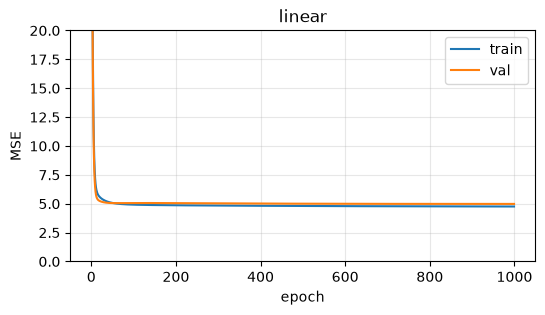

In [18]:
# лінійна регресія: nn.Linear + SGD на всьому train за раз, як у демо
set_seed()
linear = nn.Linear(len(feature_cols), 1)
train_model("linear", linear, torch.optim.SGD(linear.parameters(), lr=0.1), epochs=1000, batch_size=len(x_train_t))

plt.figure(figsize=(6, 3))
plot_curve("linear")
plt.ylim(0, 20)
plt.show()

Метрики на test, порівняння з прогнозом середнім значенням з train:

In [19]:
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mse = mean_squared_error(y_test, baseline_pred)
pd.DataFrame({
    "середнє train": {"MSE": baseline_mse, "RMSE": baseline_mse ** 0.5,
                      "MAE": mean_absolute_error(y_test, baseline_pred), "R2": r2_score(y_test, baseline_pred)},
    "linear": evaluate(linear),
}).T.round(4)

,MSE,RMSE,MAE,R2
середнє train,10.2732,3.2052,2.3522,-0.0008
linear,4.6411,2.1543,1.5584,0.5478


Ваги (ознаки стандартизовані, тому їх можна порівнювати між собою):

In [20]:
weights = pd.Series(linear.weight.detach().numpy().ravel(), index=feature_cols)
print(weights.reindex(weights.abs().sort_values(ascending=False).index).round(3))
print("bias:", round(linear.bias.item(), 3))

shucked_weight   -3.948
whole_weight      3.112
shell_weight      1.626
height            1.075
viscera_weight   -0.883
length            0.626
sex_I            -0.343
sex_M             0.034
dtype: float32
bias: 9.986


Ваги:
- Найбільші за модулем shucked_weight (-3.95) і whole_weight (+3.11). Знаки протилежні через мультиколінеарність: при тій самій загальній масі більше м'яса означає молодшого молюска, а важча мушля старшого (shell_weight +1.63). Тобто важливе саме співвідношення частин маси.
- height і length додатні: більший молюск, як правило, старший.
- sex_I = -0.34: молоді мають менше кілець, sex_M майже 0, тобто самці і самки за віком майже не відрізняються.
- bias 9.99 це середнє кількості кілець на train (ознаки стандартизовані).
Через сильну кореляцію мас окремі ваги не можна тлумачити як "чистий" вплив однієї ознаки.

#### Експеримент до питання 2: інша функція втрат

Тренував ту саму лінійну модель з MSE, MAE (L1) і Huber як функцією втрат, а оцінював усі однаково на val. Ці моделі тільки для експерименту, їх не зберігаю.

In [21]:
loss_results = {}
for loss_name, criterion in [("MSELoss", nn.MSELoss()), ("L1Loss (MAE)", nn.L1Loss()), ("HuberLoss", nn.HuberLoss())]:
    set_seed()
    m = nn.Linear(len(feature_cols), 1)
    opt = torch.optim.SGD(m.parameters(), lr=0.1)
    for epoch in range(1000):
        opt.zero_grad()
        criterion(m(x_train_t), y_train_t).backward()
        opt.step()
    with torch.no_grad():
        pred = m(x_val_t).numpy().ravel()
    loss_results[loss_name] = {"val MSE": mean_squared_error(y_val, pred),
                               "val MAE": mean_absolute_error(y_val, pred),
                               "val R2": r2_score(y_val, pred)}
pd.DataFrame(loss_results).T.round(4)

,val MSE,val MAE,val R2
MSELoss,4.9850,1.6367,0.5031
L1Loss (MAE),5.0664,1.5821,0.4950
HuberLoss,5.0419,1.5867,0.4975


Кожна функція втрат найкраща у "своїй" метриці: MSELoss дає найменшу val MSE, L1Loss найменшу val MAE, Huber посередині. Різниця невелика, бо викидів у таргеті мало. Основну модель залишаю на MSE, бо порівнюємо моделі по MSE.

### 2.3 Нейромережа: архітектури

Усі три: Adam, lr = 0.001, 200 епох, batch 64, MSELoss.
- `nn_v1`: один прихований шар 32 нейрони, ReLU
- `nn_v2`: два прихованих шари 64 і 32, ReLU (як у демо)
- `nn_v3`: ті самі 64 і 32, але Tanh замість ReLU

In [22]:
def make_nn(hidden, activation=nn.ReLU):
    layers = []
    n_in = len(feature_cols)
    for n_out in hidden:
        layers += [nn.Linear(n_in, n_out), activation()]
        n_in = n_out
    layers.append(nn.Linear(n_in, 1))
    return nn.Sequential(*layers)

# як побудувати кожну модель (потрібно, щоб потім завантажити .pt у Gradio)
builders = {"linear": lambda: nn.Linear(len(feature_cols), 1)}

for name, hidden, activation in [("nn_v1", [32], nn.ReLU),
                                 ("nn_v2", [64, 32], nn.ReLU),
                                 ("nn_v3", [64, 32], nn.Tanh)]:
    builders[name] = lambda h=hidden, a=activation: make_nn(h, a)
    set_seed()
    model = builders[name]()
    print(name, "параметрів:", sum(p.numel() for p in model.parameters()))
    train_model(name, model, torch.optim.Adam(model.parameters(), lr=0.001), epochs=200, batch_size=64)

nn_v1 параметрів: 321


nn_v1: train MSE = 4.2721, val MSE = 4.7362
nn_v2 параметрів: 2689


nn_v2: train MSE = 4.0400, val MSE = 4.7224
nn_v3 параметрів: 2689


nn_v3: train MSE = 4.0277, val MSE = 4.7897


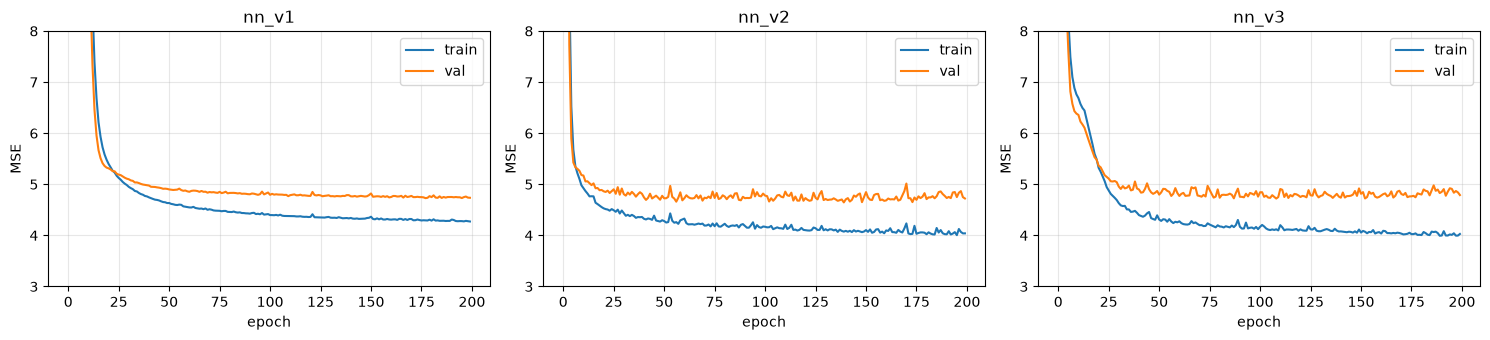

In [23]:
plt.figure(figsize=(15, 3.5))
for i, name in enumerate(["nn_v1", "nn_v2", "nn_v3"]):
    plt.subplot(1, 3, i + 1)
    plot_curve(name)
    plt.ylim(3, 8)
plt.tight_layout()
plt.show()

Порівняння архітектур (val MSE на останній епосі): nn_v2 4.722, nn_v1 4.736, nn_v3 (Tanh) 4.790. Усі три кращі за лінійну (4.985). nn_v2 і nn_v3 швидше вчаться і в них більший розрив між train і val (train 4.03-4.04, val 4.72-4.79), тобто вони трохи перенавчаються. В nn_v1 крива плавніша. Tanh вчиться повільніше на початку і в кінці гірша за ReLU. Різниця між nn_v1 і nn_v2 маленька, val скаче приблизно на ±0.1 від епохи до епохи. Далі беру nn_v2, бо в неї найменша val MSE.

### 2.4 Гіперпараметри

Беру `nn_v2` і змінюю по одному параметру відносно базових (Adam, lr 0.001, 200 епох, batch 64):
- `nn_v2_lr_0.01`: lr 0.01
- `nn_v2_lr_0.0003`: lr 0.0003
- `nn_v2_epochs_100`: 100 епох замість 200
- `nn_v2_batch_32`: batch 32
- `nn_v2_sgd`: SGD з lr 0.01 замість Adam

In [24]:
experiments = [
    ("nn_v2_lr_0.01", "adam", 0.01, 200, 64),
    ("nn_v2_lr_0.0003", "adam", 0.0003, 200, 64),
    ("nn_v2_epochs_100", "adam", 0.001, 100, 64),
    ("nn_v2_batch_32", "adam", 0.001, 200, 32),
    ("nn_v2_sgd", "sgd", 0.01, 200, 64),
]
for name, opt_name, lr, epochs, batch_size in experiments:
    builders[name] = builders["nn_v2"]
    set_seed()
    model = builders[name]()
    if opt_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_model(name, model, optimizer, epochs, batch_size)

nn_v2_lr_0.01: train MSE = 3.4227, val MSE = 5.0096


nn_v2_lr_0.0003: train MSE = 4.1473, val MSE = 4.7609


nn_v2_epochs_100: train MSE = 4.1739, val MSE = 4.8184


nn_v2_batch_32: train MSE = 3.9021, val MSE = 4.8490


nn_v2_sgd: train MSE = 3.8453, val MSE = 4.7335


Результати (val MSE на останній епосі, база nn_v2 4.722):
- lr 0.01: 5.010, гірше. Train падає до 3.42, а val ні: на кінці 5.01 і дуже скаче. Це перенавчання, крок занадто великий. Найсильніший ефект з усіх змін, але негативний.
- lr 0.0003: 4.761, вчиться повільніше, за 200 епох трохи не дотягує.
- 100 епох: 4.818. Val виходить на плато вже за ~30-50 епох, тому різниця з 200 епохами це в основному шум.
- batch 32: 4.849, більше кроків за епоху, швидше перенавчається.
- SGD (lr 0.01): 4.734, майже як Adam, але val сильніше скаче.
Жодна зміна не дала помітного покращення на val порівняно з базою.

### 2.5 Логування і порівняння

Криві val для всіх нейромереж на одному графіку:

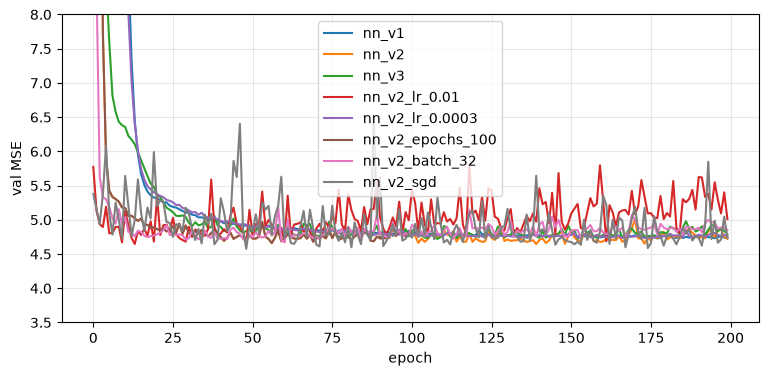

In [25]:
plt.figure(figsize=(9, 4))
for name, (train_losses, val_losses) in histories.items():
    if name != "linear":
        plt.plot(val_losses, label=name)
plt.ylim(3.5, 8)
plt.xlabel("epoch")
plt.ylabel("val MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

TensorBoard (усі запуски з `runs/`, можна накласти криві і вибрати потрібні):

In [26]:
%load_ext tensorboard
%tensorboard --logdir runs

Підсумкова таблиця на test:

In [27]:
results = pd.DataFrame([{"model": name, **evaluate(model)} for name, model in models.items()])
results.to_csv("results.csv", index=False)
results.round(4)

,model,MSE,RMSE,MAE,R2
0,linear,4.6411,2.1543,1.5584,0.5478
1,nn_v1,4.1665,2.0412,1.4635,0.5941
2,nn_v2,4.1928,2.0476,1.4243,0.5915
3,nn_v3,4.1794,2.0444,1.4220,0.5928
4,nn_v2_lr_0.01,4.8328,2.1984,1.5163,0.5292
5,nn_v2_lr_0.0003,4.1869,2.0462,1.4554,0.5921
6,nn_v2_epochs_100,4.2229,2.0550,1.4824,0.5886
7,nn_v2_batch_32,4.2675,2.0658,1.4392,0.5842
8,nn_v2_sgd,4.0763,2.0190,1.4330,0.6029


Висновки:
- **Яка модель перемогла і наскільки суттєво?** На test найкраща `nn_v2_sgd`: MSE 4.076, RMSE 2.019, MAE 1.433, R² 0.603. Лінійна: MSE 4.641, RMSE 2.154, R² 0.548. Тобто MSE менша на 12%, а в кільцях похибка RMSE менша на 0.14 кільця (6%). Але всі нейромережі, крім lr 0.01, на test дуже близькі (MSE 4.08-4.27, R² 0.58-0.60). За val найкращою була базова nn_v2, і різниця між ними менша за шум від епохи до епохи, тому чесно сказати, що nn_v2_sgd "сильно краща", не можна.
- **Чи виправдала себе нейромережа?** Так, але не сильно. Нейромережі стабільно кращі за лінійну регресію (R² ~0.59-0.60 проти 0.55), тобто в даних є нелінійна частина, ймовірно через те, що після певного віку молюск майже не росте, а кільця додаються, і лінійна модель це погано описує. Але точність у всіх моделей обмежена: похибка ~2 кільця. Вік по розмірах визначається погано: молюски одного розміру можуть мати дуже різний вік, особливо старші.
- **Що дало найбільший ефект?** Найбільший позитивний ефект дав сам перехід від лінійної моделі до нейромережі (MSE на test 4.64 -> ~4.2). Між собою архітектури відрізняються мало. З гіперпараметрів найсильніше вплинув learning rate: lr 0.01 погіршив модель найбільше (MSE на test 4.83, перенавчання). Решта змін (епохи, batch, оптимізатор) у межах шуму.

---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

Побудуйте аппку для своїх моделей

Аппка бере всі збережені `.pt` файли з `models/`, для введених вимірів показує прогноз кожної моделі і вік (кільця + 1.5). Внизу є приклади з test з відомою правильною відповіддю.

In [28]:
import gradio as gr

# завантажую моделі саме з файлів, а не з пам'яті
loaded = {}
for name in models:
    m = builders[name]()
    m.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{name}.pt")))
    m.eval()
    loaded[name] = m

def predict(sex, length, height, whole_weight, shucked_weight, viscera_weight, shell_weight):
    row = pd.DataFrame([{"sex": sex, "length": length, "height": height, "whole_weight": whole_weight,
                         "shucked_weight": shucked_weight, "viscera_weight": viscera_weight,
                         "shell_weight": shell_weight}])
    x = torch.tensor(scaler.transform(prepare(row)), dtype=torch.float32)
    with torch.no_grad():
        preds = {name: m(x).item() for name, m in loaded.items()}
    table = pd.DataFrame({"модель": list(preds.keys()),
                          "кільця": [round(v, 2) for v in preds.values()],
                          "вік, років": [round(v + 1.5, 1) for v in preds.values()]})
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(preds.keys(), preds.values())
    ax.set_ylabel("кільця")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.close(fig)
    return table, fig

# приклади з test з правильною відповіддю
examples = test_df.head(5)
example_rows = examples[["sex"] + num_cols].values.tolist()

with gr.Blocks(title="Abalone") as demo:
    gr.Markdown("## Abalone: скільки кілець у молюска\nВведіть виміри (у масштабі датасету), прогноз роблять усі моделі.")
    with gr.Row():
        with gr.Column():
            inputs = [gr.Radio(["F", "M", "I"], value="M", label="sex (F, M, I - молодий)")]
            clean_train = prepare(train_df)  # межі повзунків без помилкових height
            for col in num_cols:
                inputs.append(gr.Slider(float(clean_train[col].min()), float(clean_train[col].max()),
                                        value=float(clean_train[col].median()), label=col))
            btn = gr.Button("Порахувати")
        with gr.Column():
            out_table = gr.Dataframe(label="Прогнози")
            out_plot = gr.Plot(label="Порівняння")
    gr.Examples(example_rows, inputs, label="Приклади з test, правильні кільця: "
                + ", ".join(str(v) for v in examples[TARGET]))
    btn.click(predict, inputs, [out_table, out_plot])

demo.launch(prevent_thread_lock=True)

* Running on local URL:  http://127.0.0.1:7861


* To create a public link, set `share=True` in `launch()`.


---
### Як здавати лабу

У форму (https://forms.gle/8Dbc9zB8L5tsNuNEA) здати посилання на **публічний** репозиторій, який містить:

1. **Цей ноутбук з усіма виконаними пунктами**. Має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Файли всіх натренованих варіантів моделі** (2.2-2.4) — лінійна регресія + всі варіанти нейромережі, кожен окремим `.pt` файлом.
3. **Логи TensorBoard** — папка `runs/` з усіма прогонами, щоб можна було відкрити криві навчання, не перезапускаючи ноутбук.
4. **Таблицю результатів** — `results.csv` з порівнянням усіх варіантів (модель, MSE, RMSE, MAE, R² на test).
5. **Відео демонстрації TensorBoard & Gradio-застосунку** замість скріншотів цього разу: 60-90 секунд. На відео показуєте тренування і роботу моделей і коротко розповідаєте про цікаве (можливості, обмеження, труднощі тренування).
6. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
/lab2/nn_task.ipynb
/lab2/models/linear.pt
/lab2/models/nn_v1.pt
/lab2/models/nn_v2.pt
/lab2/models/...        (усі інші варіанти з 2.3-2.4)
/lab2/runs/*
/lab2/results.csv
/lab2/demo.mp4
```